[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thrash-lab/sparse-growth-curve/blob/main/1_one_growth_curve_analysis.ipynb)

[![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT) for the code.

[![License: CC BY-NC 4.0](https://img.shields.io/badge/License-CC%20BY--NC%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-nc/4.0/) for other contents.

#### **Authors**: Chuankai Cheng and J. Cameron Thrash(*)

Department of Biological Sciences, University of Southern California, Los Angeles, CA, USA




#### (*) Correspondence: J. Cameron Thrash
- University of Southern California
- 3616 Trousdale Pkwy, AHF 209
- Los Angeles, CA 90089, USA
- thrash@usc.edu

Here's a breakdown of the method:
- **Step 1**: We have an array of cell densities $X_i$ (can be any units, like cells/mL, OD, CFU/mL, etc.) and an array for the corresponding aquisition time $t_i$.
- **Step 2**: Calculate the instataneous doubling rates. Between every two time points, $t_i$ and $t_{i+1}$:
  - We can calculate a doubling rate, $\gamma(t=t_i)$,  between them: $\gamma(t=t_i)=\frac{log_2(X_{i+1})-log_2(X_i)}{t_{i+1}-t_i}$.
  - We call $\gamma(t=t_i)$ the **instataneous doubling rate**. 
  - When growth curve data is sparse andnoisy (like the data in this example), we need some method to get more robust estimation of the instataneous doubling rates. Here are the three approaches that we take:
    - (a) Besides calculating the instataneous doubling rates between two adjacent time points, namely $\gamma_1(t=t_i)=\frac{log_2(X_{i+1})-log_2(X_i)}{t_{i+1}-t_i}$, we also calculate the doubling rates between every other time points $\gamma_2(t=t_i)=\frac{log_2(X_{i+2})-log_2(X_i)}{t_{i+2}-t_i}$
    - (b) Besides assigning one instataneous doubling rate to one time point, we assign the instataneous doubling rates to 3 different time point: the start, middle and the end of the period. Therefore we have $\gamma_1(t=t_i)=\gamma_1(t=(t_i+t_{i+1})/2)=\gamma_1(t=t_{i+1})=\frac{log_2(X_{i+1})-log_2(X_i)}{t_{i+1}-t_i}$ and $\gamma_2(t=t_i)=\gamma_2(t=(t_i+t_{i+2})/2)=\gamma_1(t=t_{i+2})=\frac{log_2(X_{i+2})-log_2(X_i)}{t_{i+2}-t_i}$
    - (c) We merge all the $\gamma_1$ and $\gamma_2$ together, and apply a median filter sliding window to remove the outliers. And therefore, we get an array of denoised instataneous doubling rates $\gamma_{s}$ and the corresponding time $t_{s}$
  - More detail can be seen in the code of this notebook.

- **Step 3**: Seperating phases based on the instataneous doubling rates $\gamma_{s}$ and the corresponding time $t_{s}$ we got from Step 2. 
  - We are defining a growth phase as a period where the instataneous doubling rates are fairly constant. And therefore we are using decision tree regression to separate the phases.
  - Within each period of the determined growth phase, we apply linear regression to the $log_2(X_{period})$ vs. $t_{period}$ data. The slope of the linear regression is the doulbing rate of each period.

- **Step 4**: The code choose the exponential growth phase as the period where the total cell density growth has the maximum orders of magnitude.

- **Step 5**: We encapsulate all the step by step code introduced above into functions. This would make things convenient when analyzing many growth curves at the same time.



# Before started: Here are the external packages and pre-defined functions.

In [26]:
#package for numerical analysis: numpy
import numpy as np 
#package for plotting: plt
from matplotlib import pyplot as plt
import pandas as pd
#statistical analysis
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression,RANSACRegressor
from scipy import stats

#methods for 1-D interpolation: interp1d 
from scipy.interpolate import interp1d

A customized function: Linear regression with 95% confidence band: myLinearRegression_CB

In [2]:
def myLinearRegression_CB(x, y, x_fit, one_order=10):
  """
  :Authors:
    Chuankai Cheng <chuankai@usc.edu> and J. Cameron Thrash <thrash@usc.edu>
  :License:
    MIT
  :Version:
    1.0
  :Date:
    2021-03-17
  :Repository: https://github.com/thrash-lab/sparse-growth-curve
  """
  print('\nFitting data:')
  print('x = ', x)
  print('y = ', y)

  corr=np.corrcoef(x,y)[0][1]
  print('|corr|=', np.abs(corr))

  if (((np.abs(corr)<0.80) or (len(y)<4)) and 
      ((np.abs(corr)<0.90) or (len(y)<3)) and
      ((np.max(y)-np.min(y))<np.log2(one_order))):
    comp_y=np.median(y)*np.ones(len(y))
    pre_y=np.median(y)*np.ones(len(x_fit))
    doubling_rate=1e-6
  
  else:
    #Robust linear model estimation using RANSAC
    X=x.reshape(-1,1)
    if len(y)>4:
      try: 
        reg = RANSACRegressor()
        reg.fit(X, y)
        doubling_rate=reg.estimator_.coef_[0]
        inlier_mask = reg.inlier_mask_
        outlier_mask = np.logical_not(inlier_mask)
        
      except ValueError:
        print('RANSAC could not find a valid consensus set.\n',
              'Running regular linear regression.')
        reg = LinearRegression()
        reg.fit(X,y)
        doubling_rate=reg.coef_[0]
    else:
        reg = LinearRegression()
        reg.fit(X,y)
        doubling_rate=reg.coef_[0]
    
    pre_y=reg.predict(x_fit.reshape(-1,1))
    comp_y=reg.predict(X)
  
  sigma=np.sqrt(
      np.sum(
          (comp_y-y)**2
          /
          (len(x)-1))
      )

  T_95 = stats.t.ppf(0.95, len(x)-1)

  G=np.sqrt(
      1/len(x)
      +
      (x_fit-np.mean(x))**2
      /
      sum((x-np.mean(x))**2)
      )

  ci=sigma*T_95*G
  
  #sigma**2/np.sum()

  return (doubling_rate, pre_y, ci)

# Step 1: Import the growth curve data and plot

In [27]:
# import the growth curve data: time and cell density 
# (the two arrays need to be in the same length)

test_csv_path = "/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/test_growthcurve.csv"
test_file = pd.read_csv(test_csv_path)

time=np.array([  0.   ,  17.75 ,  24.   ,  42.5  ,  47.17 ,  65.75 ,  71.5  ,
        88.5  ,  95.33 , 160.33 , 167.497]
        )

cell_density=np.array([8445.6, 512116.9, 3801502, 437134, 4105945,
                       3518974, 3245031, 3368960, 3362095, 2628343,
                       2654070])

time = test_file["Elapsed"]
cell_density= test_file["Confluence"]

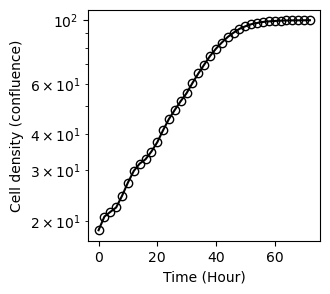

In [30]:
%matplotlib inline
plt.figure(figsize=(3,3))

#'k' means black, 'o' means circle
# mfc='none' means empty shape
plt.plot(time, cell_density,
         'o-',
         color='k',
         mfc='none')

plt.xlabel('Time (Hour)')
plt.ylabel('Cell density (confluence)')
plt.yscale('log')

#plt.savefig('./1_growth_curve.pdf')
plt.show()

In [32]:
t=time
X=cell_density

t1=np.array(t)
X1=np.array(X)

t_o=np.array(t)
X_o=np.array(X)


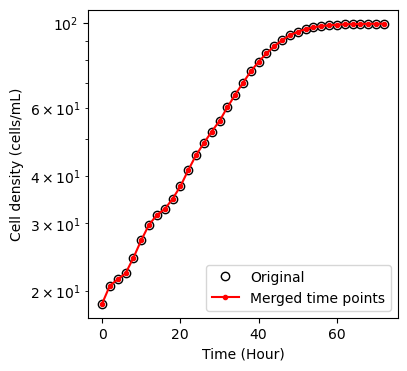

In [33]:
#for i in range(len(t)-3):
#  t1=np.r_[t1,np.median(t[[i,i+1,i+2]])]
#  X1=np.r_[X1, np.median(X[[i,i+1, i+2]])]


#You might get multiple cell counts for the same sample at one time.
#In my example, I have two cell counts on day 15.
#Here, I merge the cell densities by their mean:

#using the function "np.unique"
#I get rid of the duplicated time points
t=np.unique(t1) 

X=[]
for tt in np.unique(t1):
  temporary_cell_densities=X1[t1==tt]
  #Getting the mean cell density at a time point
  X.append(np.median(temporary_cell_densities))
X=np.array(X)

X=X[np.argsort(t)]
t=t[np.argsort(t)]

%matplotlib inline
plt.figure(figsize=(4,4))

#'k' means black, 'o' means circle
# mfc='none' means empty shape
plt.plot(time, cell_density,
         'o',
         color='k',
         mfc='none', 
         label='Original')

#'r' means red, 
#'.-' means connected dot
plt.plot(t, X,
         '.-',
         color='r',
         label='Merged time points')

plt.legend()
plt.xlabel('Time (Hour)')
plt.ylabel('Cell density (cells/mL)')
plt.yscale('log')

plt.savefig('./2_growth_curve_time_merged.pdf')

plt.show()

# Step 2: Get the "instantaneous" doubling rates

Assuming that our growth curve is $X(t)$. The "instataneous" doubling rate $\gamma (t)$ can then be calculated as:

## $\gamma (t)=\frac{\mathrm{d}\ \mathrm{log_2}(X(t))}{\mathrm{d}\ t}$ 

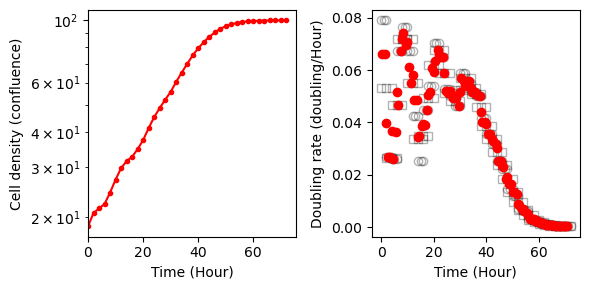

In [35]:
%matplotlib inline

gamma=np.diff(np.log2(X))/np.diff(t)
gamma=np.r_[gamma, gamma, gamma]
#gamma=np.r_[gamma[0], gamma]
t_gamma=np.r_[t[0:-1],
              np.array([(t[i]+t[i+1])/2 for i in range(len(t)-1)]),
              t[1::]]

gamma_2=np.diff(np.log2(X)[::2])/np.diff(t[::2])
gamma_2=np.r_[gamma_2, gamma_2, gamma_2]
t_gamma_2=np.r_[t[::2][0:-1],
                [(t[::2][i]+t[::2][i+1])/2 for i in range(len(t[::2])-1)],
                t[::2][1::]]

gamma_2_1=np.diff(np.log2(X)[1::2])/np.diff(t[1::2])
gamma_2_1=np.r_[gamma_2_1, gamma_2_1, gamma_2_1]
t_gamma_2_1=np.r_[t[1::2][0:-1],
                [(t[1::2][i]+t[1::2][i+1])/2 for i in range(len(t[1::2])-1)],
                t[1::2][1::]]


#gamma_3=np.diff(np.log2(X)[::3])/np.diff(t[::3])
#gamma_3=np.r_[gamma_3, gamma_3, gamma_3]
#t_gamma_3=np.r_[t[::3][0:-1],
#                [(t[::3][i]+t[::3][i+1])/2 for i in range(len(t[::3])-1)],
#                t[::3][1::]]

plt.figure(figsize=(6,3))

plt.subplot(121)
plt.plot(t, X, 'r.-')

plt.xlim(left=0)
plt.yscale('log')
plt.xlabel('Time (Hour)')
plt.ylabel('Cell density (confluence)')

plt.subplot(122)
plt.plot(t_gamma, 
         gamma, 
         'ko', mfc='none', alpha=0.3)

plt.plot(t_gamma_2, 
         gamma_2, 
         'ks', mfc='none', alpha=0.3)

plt.plot(t_gamma_2_1, 
         gamma_2_1, 
         'ks', mfc='none', alpha=0.3)

#plt.plot(t_gamma_3, 
#         gamma_3, 
#         'k^',mfc='none', alpha=0.3)

all_t_gamma=np.r_[t_gamma,t_gamma_2, t_gamma_2_1]
all_gamma=np.r_[gamma, gamma_2, gamma_2_1]

all_gamma=all_gamma[np.argsort(all_t_gamma)]
all_t_gamma=np.sort(all_t_gamma)

all_gamma=np.array([np.median(all_gamma[[i,i+1,i+2,i+3]]) 
                    for i in range(len(all_t_gamma)-4)])
all_t_gamma=np.array([np.median(all_t_gamma[[i,i+1,i+2,i+3]]) 
                    for i in range(len(all_t_gamma)-4)])

sel_t_gamma=np.unique(all_t_gamma)
sel_gamma=[]
for stg in sel_t_gamma:
  sel_gamma.append(
      np.median(all_gamma[all_t_gamma==stg]))
sel_gamma=np.array(sel_gamma)

plt.plot(sel_t_gamma, sel_gamma, 'ro')
#plt.xlim(left=0)

plt.xlabel('Time (Hour)')
plt.ylabel('Doubling rate (doubling/Hour)')

plt.tight_layout()

plt.savefig('./3_growth_curve_doubling_rates.pdf')
plt.show()

# Step 3: Fitting the growth curve

Based on the growth curve and the instataneous growth rates showing above, we want to separate different phases (lag, exponential, and stationary). We also want to do this automatically.

- Here, we use the method called "DecisionTreeRegressor"
- More about DecisionTreeRegressor: https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html#sphx-glr-auto-examples-tree-plot-tree-regression-py

In [36]:
# The max_depth here I set is 1
# Because for a standard growth curve (no diauxic shift) without death phase,
# there would only be two states:
# 1. Not growing (lag phase and stationary), growth rate is close to 0;
# 2. Growing exponentially at an almost constant rate.

regr_1 = DecisionTreeRegressor(max_depth=1)
regr_1.fit(sel_t_gamma.reshape(-1, 1), 
           sel_gamma)

DecisionTreeRegressor(max_depth=1)

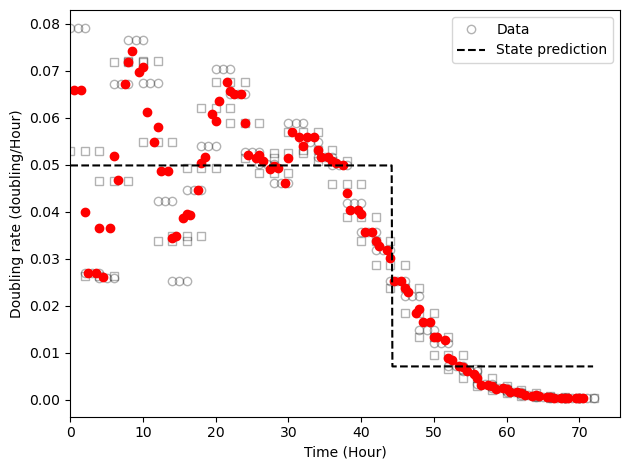

In [37]:
%matplotlib inline

t_1 = np.arange(0.0, t[-1], 0.1)[:, np.newaxis]
gamma_1 = regr_1.predict(t_1)

plt.plot(t_gamma, 
         gamma, 
         'ko', mfc='none', label='Data', alpha=0.3)

plt.plot(t_gamma_2, 
         gamma_2, 
         'ks', mfc='none', alpha=0.3)

plt.plot(t_gamma_2_1, 
         gamma_2_1, 
         'ks', mfc='none', alpha=0.3)

plt.plot(sel_t_gamma, sel_gamma, 'ro')

plt.plot(t_1, 
         gamma_1, 
         'k--', label='State prediction')

plt.xlim(left=0)

plt.xlabel('Time (Hour)')
plt.ylabel('Doubling rate (doubling/Hour)')

plt.legend()

plt.savefig('4_state_prediction.pdf')
plt.tight_layout()

The prediction plot above shows that the algorithm estimated 0--25 hours as one phase (**presumably** the exponential phase). After 25 hours would be another phase (**presumably** the stationary phase). Perhaps due to the short lag period, the prediction does not return a lag phase.
- We use the word **presumably** because we want the software to determine the exponential phase later (this is non-trivial).
- Also, even though the state predictions gave their estimation of doubling rates: 0.3 doubling/hour between 0 and 25 hours, 0.01 doubling/hour between 25 and 170 hours, we want the doubling rates be recalculated through **linear regressions**.

In [39]:
#First, we find the state transition point
gamma_1_diff=np.diff(gamma_1)
inflection_points=t_1[1::][gamma_1_diff!=0]

print(inflection_points)

[[44.3]]


In [40]:
all_starting_time=np.r_[[0],inflection_points.reshape(1,-1)[0], t_1[-1]]
print(all_starting_time)

[ 0.  44.3 71.9]


Here, we have the starting time as 0 hours, 25.6 hours, and 167.4 hours, which means we will be doing linear regressions for **two periods**:
- 0 to 25.6 hours
- 25.6 to 167.4 hours

In [41]:
all_doubling_rates=[]
all_fit_time=[]
all_fit_cell_density=[]
all_fit_conf_band=[]

for i in range(len(all_starting_time)-1):
  start_t=all_starting_time[i]
  end_t=all_starting_time[i+1]

  print('Time period: ', start_t, 'hours  ---', end_t, 'hours')

  # Chooseing the time period:
  sel_bool=(t>=start_t-1) & (t<=end_t+1)
  #if np.sum(sel_bool)<3:
  #  if np.where(sel_bool)[0][0]!=0 and np.where(sel_bool)[0][-1]!=len(sel_bool)-1:
  #    sel_bool[np.where(sel_bool)[0][0]-1]=True
  #    #sel_bool[np.where(sel_bool)[0][-1]+1]=True
  #  elif np.where(sel_bool)[0][0]!=0:
  #    sel_bool[np.where(sel_bool)[0][0]-1]=True
  #  elif np.where(sel_bool)[0][-1]!=len(sel_bool)-1:
  #    sel_bool[np.where(sel_bool)[0][-1]+1]=True

  if np.sum(sel_bool)>=2:
    sel_t=t[sel_bool]
    sel_X=X[sel_bool]

    #print(sel_t, sel_X)

    fit_bool=(t_1>=start_t-1) & (t_1<=end_t+1)
    sel_t_1=t_1[fit_bool]

    (dr, pre_X_1, ci)=myLinearRegression_CB(
        sel_t, 
        np.log2(sel_X), 
        sel_t_1)
    
    all_doubling_rates.append(dr)
    all_fit_time.append(sel_t_1)
    all_fit_cell_density.append(2**pre_X_1)
    all_fit_conf_band.append(2**ci)

    print('Doubling rate:', dr, 'doubling/hour')
    print('\n')

  else:
    print('No data point in this time period, not fitting.')

Time period:  0.0 hours  --- 44.300000000000004 hours

Fitting data:
x =  [ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44]
y =  [4.21020415 4.36825361 4.42208563 4.47386482 4.60815929 4.76138156
 4.89624375 4.98094064 5.03125667 5.12060285 5.22845701 5.36904415
 5.4991545  5.60442009 5.70473643 5.79700312 5.91496365 6.02474032
 6.12788292 6.22780903 6.31152182 6.38292969 6.44656409]
|corr|= 0.9988984415394817
Doubling rate: 0.05218282523476981 doubling/hour


Time period:  44.300000000000004 hours  --- 71.9 hours

Fitting data:
x =  [44 46 48 50 52 54 56 58 60 62 64 66 68 70 72]
y =  [6.44656409 6.49724813 6.54132665 6.57077621 6.59474291 6.60895454
 6.62116044 6.6276598  6.63251398 6.63589787 6.6379807  6.63925431
 6.63991499 6.64047242 6.64101966]
|corr|= 0.8511912655690083
Doubling rate: 0.0015374235075447523 doubling/hour




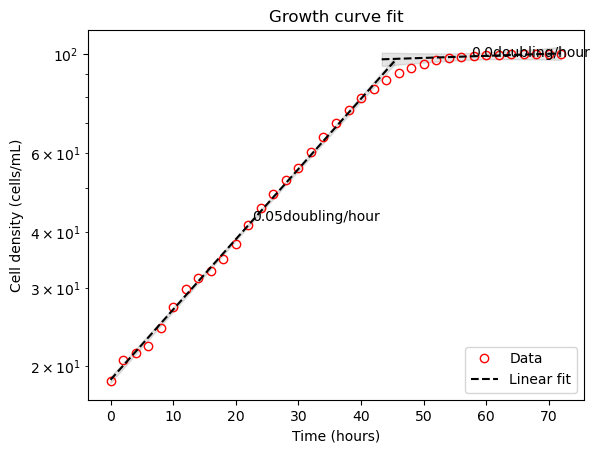

In [43]:
%matplotlib inline

plt.plot(t, X, 'ro', mfc='none', label='Data')

for i in range(len(all_doubling_rates)):
  if i==0:
    plt.plot(all_fit_time[i], all_fit_cell_density[i], 'k--',
            label='Linear fit')
  else:
    plt.plot(all_fit_time[i], all_fit_cell_density[i], 'k--',
            label='_nolegend_')
    
  plt.fill_between(all_fit_time[i], 
                   all_fit_cell_density[i]*all_fit_conf_band[i],
                   all_fit_cell_density[i]/all_fit_conf_band[i],
                   color='k', alpha=0.1)
      
  plt.text(np.median(all_fit_time[i]), 
           2**np.median(np.log2(all_fit_cell_density[i])),
           str(np.round(all_doubling_rates[i],2))+'doubling/hour')

plt.xlabel('Time (hours)')
plt.ylabel('Cell density (cells/mL)')
plt.yscale('log')
plt.title('Growth curve fit')
plt.legend(loc=4)

plt.savefig('5_growth_curve_fit.pdf')
plt.show()

# Step 4: Which phase is the exponential phase?

We designed the algorithm to define the phase that crosses the most orders of magnitude as the exponential phase.

In [44]:
all_acrossing_orders=[]
for i in range(len(all_fit_cell_density)):
  start_t=all_fit_time[i][0]
  end_t=all_fit_time[i][-1]

  print('Time period: ', start_t, 'hours  ---', end_t, 'hours')

  afc = all_fit_cell_density[i]
  acrossing_orders=np.log10(afc[-1])-np.log10(afc[0])
  all_acrossing_orders.append(acrossing_orders)
  
  print('Doubling rate:', all_doubling_rates[i], 'doubling/hour')
  print('Number of orders acrossing:', acrossing_orders)
  print('\n')

Time period:  0.0 hours  --- 45.300000000000004 hours
Doubling rate: 0.05218282523476981 doubling/hour
Number of orders acrossing: 0.7115993831333141


Time period:  43.300000000000004 hours  --- 71.9 hours
Doubling rate: 0.0015374235075447523 doubling/hour
Number of orders acrossing: 0.013236382925763124




In [45]:
selected_i=np.argmax(all_acrossing_orders)
selected_doubling_rate=all_doubling_rates[selected_i]
selected_fit_time=all_fit_time[selected_i]
selected_fit_cell_density=all_fit_cell_density[selected_i]

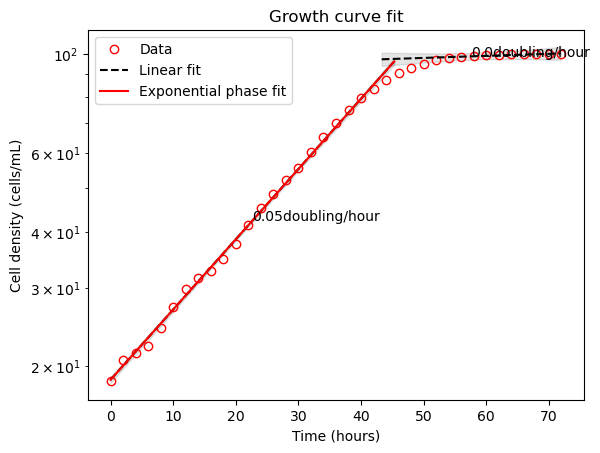

In [46]:
%matplotlib inline

plt.plot(t_o, X_o, 'ro', mfc='none', label='Data')

for i in range(len(all_doubling_rates)):
  if i==0:
    plt.plot(all_fit_time[i], all_fit_cell_density[i], 'k--',
            label='Linear fit')
  else:
    plt.plot(all_fit_time[i], all_fit_cell_density[i], 'k--',
            label='_nolegend_')
    
  plt.fill_between(all_fit_time[i], 
                   all_fit_cell_density[i]*(all_fit_conf_band[i]),
                   all_fit_cell_density[i]/(all_fit_conf_band[i]),
                   color='k', alpha=0.1)
    
  plt.text(np.median(all_fit_time[i]), 
           2**np.median(np.log2(all_fit_cell_density[i])),
           str(np.round(all_doubling_rates[i],2))+'doubling/hour')

plt.plot(selected_fit_time, selected_fit_cell_density,'r-',
         label='Exponential phase fit')
plt.xlabel('Time (hours)')
plt.ylabel('Cell density (cells/mL)')
plt.yscale('log')
plt.title('Growth curve fit')
plt.legend()

plt.savefig('6_exponential_phase.pdf')
plt.show()

In [47]:
print('The doubling rate for exponential phase is:', 
      selected_doubling_rate, 'doubling/hour', '\n')

print('The doubling time is:',
      1/selected_doubling_rate, 'hour/doubling','\n')

print('Converting to specific growth rate, we have:',
      np.log(2)*selected_doubling_rate, 'doubling/hour', '\n')

The doubling rate for exponential phase is: 0.05218282523476981 doubling/hour 

The doubling time is: 19.16339323332943 hour/doubling 

Converting to specific growth rate, we have: 0.03617037818513306 doubling/hour 



# Step 5: Wrapping up the code in functions.

In [48]:
def preprocessing_growth_curve(time, cell_density):
  """
  :Authors:
    Chuankai Cheng <chuankai@usc.edu> and J. Cameron Thrash <thrash@usc.edu>
  :License:
    MIT
  :Version:
    1.0
  :Date:
    2021-03-17
  :Repository: https://github.com/thrash-lab/sparse-growth-curve
  """
  t=np.array(time)
  X=np.array(cell_density)

  #for i in range(len(time)-3):
  #  t=np.r_[t,np.median(time[[i,i+1,i+2]])]
  #  X=np.r_[X, np.median(cell_density[[i,i+1, i+2]])]

  X=X[np.argsort(t)]
  t=t[np.argsort(t)]

  #You might get multiple cell counts for the same sample at one time.
  #Here, I merge the cell densities by their mean:
  #using the function "np.unique"
  #I get rid of the duplicated time points
  t1=np.unique(t) 
  X1=[]
  for tt in t1:
    temporary_cell_densities=X[t==tt]
    #Getting the mean cell density at a time point
    X1.append(np.median(temporary_cell_densities))
  X1=np.array(X1)

  return t1, X1

In [49]:
def phase_seperations(t, X, max_depth=1):
  """
  :Authors:
    Chuankai Cheng <chuankai@usc.edu> and J. Cameron Thrash <thrash@usc.edu>
  :License:
    MIT
  :Version:
    1.0
  :Date:
    2021-03-17
  :Repository: https://github.com/thrash-lab/sparse-growth-curve
  """
  gamma=np.diff(np.log2(X))/np.diff(t)
  gamma=np.r_[gamma, gamma, gamma]
  #gamma=np.r_[gamma[0], gamma]
  t_gamma=np.r_[t[0:-1],
                np.array([(t[i]+t[i+1])/2 for i in range(len(t)-1)]),
                t[1::]]

  gamma_2=np.diff(np.log2(X)[::2])/np.diff(t[::2])
  gamma_2=np.r_[gamma_2, gamma_2, gamma_2]
  t_gamma_2=np.r_[t[::2][0:-1],
                  [(t[::2][i]+t[::2][i+1])/2 for i in range(len(t[::2])-1)],
                  t[::2][1::]]


  gamma_2_1=np.diff(np.log2(X)[1::2])/np.diff(t[1::2])
  gamma_2_1=np.r_[gamma_2_1, gamma_2_1, gamma_2_1]
  t_gamma_2_1=np.r_[t[1::2][0:-1],
                  [(t[1::2][i]+t[1::2][i+1])/2 for i in range(len(t[1::2])-1)],
                  t[1::2][1::]]


  #gamma_3=np.diff(np.log2(X)[::3])/np.diff(t[::3])
  #gamma_3=np.r_[gamma_3, gamma_3, gamma_3]
  #t_gamma_3=np.r_[t[::3][0:-1],
  #                [(t[::3][i]+t[::3][i+1])/2 for i in range(len(t[::3])-1)],
  #                t[::3][1::]]

  all_t_gamma=np.r_[t_gamma,t_gamma_2, t_gamma_2_1]
  all_gamma=np.r_[gamma, gamma_2, gamma_2_1]

  all_gamma=all_gamma[np.argsort(all_t_gamma)]
  all_t_gamma=np.sort(all_t_gamma)

  all_gamma=np.array([np.median(all_gamma[[i,i+1,i+2,i+3]]) 
                      for i in range(len(all_t_gamma)-4)])
  all_t_gamma=np.array([np.median(all_t_gamma[[i,i+1,i+2,i+3]]) 
                      for i in range(len(all_t_gamma)-4)])

  sel_t_gamma=np.unique(all_t_gamma)
  sel_gamma=[]
  for stg in sel_t_gamma:
    sel_gamma.append(
        np.mean(all_gamma[all_t_gamma==stg]))
  sel_gamma=np.array(sel_gamma)

  #print(sel_gamma)
  #print(sel_t_gamma)
  # By default, max_depth = 1
  # Because for a standard growth curve (no diauxic shift) without death phase,
  # there would only be two states:
  # 1. Not growing (lag phase and stationary), growth rate is close to 0;
  # 2. Growing exponentially at an almost constant rate.

  regr_1 = DecisionTreeRegressor(max_depth=max_depth)
  regr_1.fit(sel_t_gamma.reshape(-1, 1), sel_gamma)

  t_fit = np.arange(0.0, t[-1], 0.01)[:, np.newaxis]
  gamma_fit = regr_1.predict(t_fit)

  #print(gamma_fit)
  #We find the state transition point
  gamma_fit_diff=np.diff(gamma_fit)
  inflection_points=t_fit[1::][gamma_fit_diff!=0]

  all_starting_time=np.r_[[0],inflection_points.reshape(1,-1)[0], t_fit[-1]]

  return all_starting_time

In [50]:
def phases_exponential_fit(phases_points, t, X, one_order):
  """
  :Authors:
    Chuankai Cheng <chuankai@usc.edu> and J. Cameron Thrash <thrash@usc.edu>
  :License:
    MIT
  :Version:
    1.0
  :Date:
    2021-03-17
  :Repository: https://github.com/thrash-lab/sparse-growth-curve
  """
  all_starting_time=phases_points

  all_doubling_rates=[]
  all_fit_time=[]
  all_fit_cell_density=[]
  all_fit_conf_band=[]

  print('All phases points', all_starting_time)
  t_1 = np.arange(0.0, t[-1], 0.01)[:, np.newaxis]
  
  for i in range(len(all_starting_time)-1):
    start_t=all_starting_time[i]
    end_t=all_starting_time[i+1]

    #print('Time period: ', start_t, 'hours  ---', end_t, 'hours')
    # Chooseing the time period:
    sel_bool=(t>=start_t-1) & (t<=end_t+1)
    #if np.sum(sel_bool)<3:
    #  if np.where(sel_bool)[0][0]!=0 and np.where(sel_bool)[0][-1]!=len(sel_bool)-1:
    #    sel_bool[np.where(sel_bool)[0][0]-1]=True
    #    sel_bool[np.where(sel_bool)[0][-1]+1]=True
    #  elif np.where(sel_bool)[0][0]!=0:
    #    sel_bool[np.where(sel_bool)[0][0]-1]=True
    #  elif np.where(sel_bool)[0][-1]!=len(sel_bool)-1:
    #    sel_bool[np.where(sel_bool)[0][-1]+1]=True

    if np.sum(sel_bool)>=2:
      sel_t=t[sel_bool]
      sel_X=X[sel_bool]

      #print(sel_t, sel_X)

      fit_bool=(t_1>=start_t-1) & (t_1<=end_t+1)
      sel_t_1=t_1[fit_bool]

      (dr, pre_X_1, ci)=myLinearRegression_CB(
          sel_t, 
          np.log2(sel_X), 
          sel_t_1)
      
      all_doubling_rates.append(dr)
      all_fit_time.append(sel_t_1)
      all_fit_cell_density.append(2**pre_X_1)
      all_fit_conf_band.append(2**ci)

      print('Doubling rate:', dr, 'doubling/hour')
      print('\n')

    else:
      print('No data point in this time period, not fitting.')

  return (all_doubling_rates,
            all_fit_time,
            all_fit_cell_density,
            all_fit_conf_band)

In [51]:
def growth_death_rate_decision(all_fit_cell_density,
                               all_fit_time,
                               all_doubling_rates):
  """
  :Authors:
    Chuankai Cheng <chuankai@usc.edu> and J. Cameron Thrash <thrash@usc.edu>
  :License:
    MIT
  :Version:
    1.0
  :Date:
    2021-03-17
  :Repository: https://github.com/thrash-lab/sparse-growth-curve
  """
  #all_starting_time=phases_points
  all_acrossing_orders=[]
  for i in range(len(all_fit_cell_density)):
    start_t=all_fit_time[i][0]
    end_t=all_fit_time[i][-1]

    print('\nTime period: ', start_t, 'hours  ---', end_t, 'hours')

    afc = all_fit_cell_density[i]
    acrossing_orders=np.log10(afc[-1])-np.log10(afc[0])
    all_acrossing_orders.append(acrossing_orders)
    
    print('Doubling rate:', all_doubling_rates[i], 'doubling/hour')
    print('Number of orders acrossing:', acrossing_orders)

  selected_doubling_rate=0
  selected_fit_time=0
  selected_fit_cell_density=all_fit_cell_density[0][0]

  selected_doubling_rate_d=0
  selected_fit_time_d=all_fit_time[-1][-1]
  selected_fit_cell_density_d=all_fit_cell_density[-1][-1]

  #Growth phase:
  if max(all_acrossing_orders)>0:
    selected_i=np.argmax(all_acrossing_orders)
    selected_doubling_rate=all_doubling_rates[selected_i]
    selected_fit_time=all_fit_time[selected_i]
    selected_fit_cell_density=all_fit_cell_density[selected_i]

  #Death phase:
  if min(all_acrossing_orders)<0:
    selected_i_d=np.argmin(all_acrossing_orders)
    selected_doubling_rate_d=all_doubling_rates[selected_i_d]
    selected_fit_time_d=all_fit_time[selected_i_d]
    selected_fit_cell_density_d=all_fit_cell_density[selected_i_d]

  return (selected_doubling_rate,
          selected_fit_time,
          selected_fit_cell_density,
          selected_doubling_rate_d,
          selected_fit_time_d,
          selected_fit_cell_density_d)

In [52]:
def fit_growth_curve(time, cell_density, one_order=10, decision_tree_depth=1):
  """
  :Authors:
    Chuankai Cheng <chuankai@usc.edu> and J. Cameron Thrash <thrash@usc.edu>
  :License:
    MIT
  :Version:
    1.0
  :Date:
    2021-03-17
  :Repository: https://github.com/thrash-lab/sparse-growth-curve
  """
  t1,X1=preprocessing_growth_curve(time, cell_density)
  phases_points=phase_seperations(t1, X1, max_depth=decision_tree_depth)

  print(phases_points)
  
  (all_doubling_rates,
            all_fit_time,
            all_fit_cell_density,
            all_fit_conf_band)=phases_exponential_fit(phases_points, t1, X1, 
                                                 one_order)

  (selected_doubling_rate,
          selected_fit_time,
          selected_fit_cell_density,
          selected_doubling_rate_d,
          selected_fit_time_d,
          selected_fit_cell_density_d)=growth_death_rate_decision(
                               all_fit_cell_density,
                               all_fit_time,
                               all_doubling_rates)
          
  return (all_fit_time,
          all_fit_cell_density,
          all_fit_conf_band,
          selected_doubling_rate,
          selected_fit_time,
          selected_fit_cell_density,
          selected_doubling_rate_d,
          selected_fit_time_d,
          selected_fit_cell_density_d)

In [53]:
(all_fit_time,
          all_fit_cell_density,
          all_fit_conf_band,
          selected_doubling_rate,
          selected_fit_time,
          selected_fit_cell_density,
          selected_doubling_rate_d,
          selected_fit_time_d,
          selected_fit_cell_density_d)=fit_growth_curve(
              time, cell_density, one_order=10, decision_tree_depth=1)

[ 0.   44.26 71.99]
All phases points [ 0.   44.26 71.99]

Fitting data:
x =  [ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44]
y =  [4.21020415 4.36825361 4.42208563 4.47386482 4.60815929 4.76138156
 4.89624375 4.98094064 5.03125667 5.12060285 5.22845701 5.36904415
 5.4991545  5.60442009 5.70473643 5.79700312 5.91496365 6.02474032
 6.12788292 6.22780903 6.31152182 6.38292969 6.44656409]
|corr|= 0.9988984415394817
Doubling rate: 0.05218282523476981 doubling/hour



Fitting data:
x =  [44 46 48 50 52 54 56 58 60 62 64 66 68 70 72]
y =  [6.44656409 6.49724813 6.54132665 6.57077621 6.59474291 6.60895454
 6.62116044 6.6276598  6.63251398 6.63589787 6.6379807  6.63925431
 6.63991499 6.64047242 6.64101966]
|corr|= 0.8511912655690083
Doubling rate: 0.0015374235075447523 doubling/hour



Time period:  0.0 hours  --- 45.26 hours
Doubling rate: 0.05218282523476981 doubling/hour
Number of orders acrossing: 0.710971039307148

Time period:  43.26 hours  --- 71.99 hours
Doubling

In [57]:
def fit_growth_curve_ransac_method(time, cell_density):
  """
  :Authors:
    Chuankai Cheng <chuankai@usc.edu> and J. Cameron Thrash <thrash@usc.edu>
  :License:
    MIT
  :Version:
    1.0
  :Date:
    2021-03-17
  :Repository: https://github.com/thrash-lab/sparse-growth-curve
  """
  outlier_mask=np.array([True for i in range(len(cell_density))])
  t_ransac=time[outlier_mask]
  cd_ransac=cell_density[outlier_mask]

  all_ransac_periods=[]
  all_ransac_periods_cd=[]
  all_ransac_periods_order=[]
  all_ransac_periods_doubling_rate=[]
  p=1
  while len(t_ransac)>2:
    reg = RANSACRegressor()
    reg.fit(t_ransac.reshape(-1,1), np.log2(cd_ransac))
    inlier_mask = reg.inlier_mask_

    print('\nPeriod', p, ':')
    cd_fit=2**(reg.predict(t_ransac[inlier_mask].reshape(-1,1)))

    all_ransac_periods.append(t_ransac[inlier_mask])
    all_ransac_periods_cd.append(cd_fit)

    print('Time=', t_ransac[inlier_mask], 
          '\nCell density=', cd_ransac[inlier_mask], 
          '\nFit cell density=', cd_fit)
    print('Doubling rate=', reg.estimator_.coef_[0], 'Doubling/hour')
    orders=np.log10(cd_fit[-1]/cd_fit[0])
    print('Orders acorssing=', orders)
    all_ransac_periods_doubling_rate.append(reg.estimator_.coef_[0])
    all_ransac_periods_order.append(orders)

    outlier_mask = np.logical_not(inlier_mask)
    
    t_ransac=t_ransac[outlier_mask]
    cd_ransac=cd_ransac[outlier_mask]

    p+=1

  ransac_selected_doubling_rate=all_ransac_periods_doubling_rate[np.argmax(all_ransac_periods_order)]
  ransac_selected_doubling_rate_d=all_ransac_periods_doubling_rate[np.argmin(all_ransac_periods_order)]

  ransac_selected_periods=all_ransac_periods[np.argmax(all_ransac_periods_order)]
  ransac_selected_periods_d=all_ransac_periods[np.argmin(all_ransac_periods_order)]

  ransac_selected_periods_cd=all_ransac_periods_cd[np.argmax(all_ransac_periods_order)]
  ransac_selected_periods_cd_d=all_ransac_periods_cd[np.argmin(all_ransac_periods_order)]
  
  return (all_ransac_periods,
          all_ransac_periods_cd,
          all_ransac_periods_order,
          all_ransac_periods_doubling_rate,
          ransac_selected_doubling_rate,
          ransac_selected_doubling_rate_d,
          ransac_selected_periods,
          ransac_selected_periods_d,
          ransac_selected_periods_cd,
          ransac_selected_periods_cd_d)

In [62]:
(all_ransac_periods,
          all_ransac_periods_cd,
          all_ransac_periods_order,
          all_ransac_periods_doubling_rate,
          ransac_selected_doubling_rate,
          ransac_selected_doubling_rate_d,
          ransac_selected_periods,
          ransac_selected_periods_d,
          ransac_selected_periods_cd,
          ransac_selected_periods_cd_d)=fit_growth_curve_ransac_method(time.to_numpy(), cell_density.to_numpy())


Period 1 :
Time= [ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58] 
Cell density= [18.50963 20.65263 21.43781 22.2212  24.38901 27.12181 29.77942 31.58003
 32.70086 34.79005 37.4906  41.3279  45.22832 48.65176 52.1551  55.59962
 60.33669 65.10698 69.9321  74.94753 79.42503 83.45518 87.21861 90.33719
 93.13985 95.06064 96.65302 97.60983 98.43916 98.88363] 
Fit cell density= [ 20.2346294   21.54611064  22.94259383  24.42958827  26.01296032
  27.69895658  29.4942285   31.40585864  33.4413886   35.6088488
  37.91679011  40.37431765  42.99112664  45.77754071  48.74455259
  51.9038675   55.2679493   58.85006969  62.66436057  66.72586976
  71.0506204   75.65567414  80.55919846  85.78053834  91.34029259
  97.2603951  103.56420136 110.27658065 117.42401408 125.03469914]
Doubling rate= 0.0453005205263242 Doubling/hour
Orders acorssing= 0.7909352988616969

Period 2 :
Time= [64 66 68 70 72] 
Cell density= [99.59357 99.68153 99.72719 99.76573 99.80358] 
F

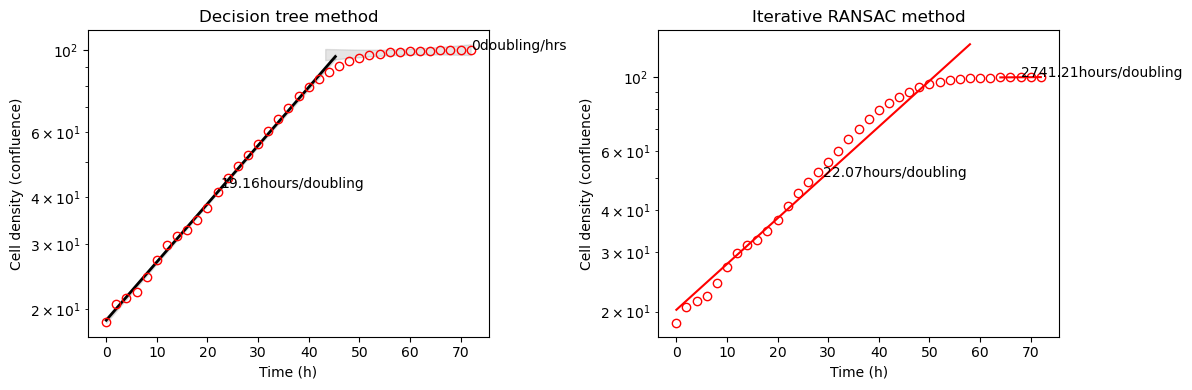

In [68]:
%matplotlib inline
plt.figure(figsize=(12,4))

plt.subplot(121)
for i in range(len(all_fit_time)):
  #plt.plot(all_fit_time[i], all_fit_cell_density[i], 'k--')
  plt.fill_between(all_fit_time[i], 
                   all_fit_cell_density[i]*(all_fit_conf_band[i]),
                   all_fit_cell_density[i]/(all_fit_conf_band[i]),
                   color='k', alpha=0.1)
  
plt.plot(selected_fit_time, selected_fit_cell_density, 'k-',
         linewidth=2)

plt.text(
    np.median(selected_fit_time),
    2 ** np.median(np.log2(selected_fit_cell_density)),
    str(np.round(1 / selected_doubling_rate, 2)) + "hours/doubling",
)

plt.plot(selected_fit_time_d, selected_fit_cell_density_d, 'k--', 
         linewidth=2)

plt.text(np.median(selected_fit_time_d), 
           2**np.median(np.log2(selected_fit_cell_density_d)),
           str(np.round(selected_doubling_rate_d,2))+'doubling/hrs')

plt.plot(time, cell_density, 'ro', mfc='none')


plt.xlabel('Time (h)')
plt.ylabel("Cell density (confluence)")

plt.yscale('log')
plt.title('Decision tree method')

plt.subplot(122)
for i in range(len(all_ransac_periods)):
  plt.plot(all_ransac_periods[i], all_ransac_periods_cd[i], 'r-')
  plt.text(np.median(all_ransac_periods[i]),
           2**np.median(np.log2(all_ransac_periods_cd[i])),
           str(np.round(1/all_ransac_periods_doubling_rate[i],2))+'hours/doubling')
  
  
plt.plot(time, cell_density, 'ro', mfc='none')


plt.xlabel('Time (h)')
plt.ylabel('Cell density (confluence)')

plt.yscale('log')
plt.title('Iterative RANSAC method')

plt.tight_layout()

plt.savefig('Methods_comparison.pdf')
plt.show()